# **Fase 2 - Fase 2 - Projeto Em Business Intelligence e Analytics**
# Ruan Marinho da Silva

In [35]:
# Importação das bibliotecas

import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [17]:
# Leitura dos arquivos CSV

orders = pd.read_csv("olist_orders_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

print("Arquivos carregados com sucesso!")

print("\nTamanho das bases:")
print("Orders:", orders.shape)
print("Payments:", payments.shape)
print("Items:", items.shape)
print("Reviews:", reviews.shape)

Arquivos carregados com sucesso!

Tamanho das bases:
Orders: (99441, 8)
Payments: (103886, 5)
Items: (112650, 7)
Reviews: (99224, 7)


In [18]:
# Conferência das colunas

print("Colunas da base Orders:")
print(orders.columns.tolist())

print("\nColunas da base Payments:")
print(payments.columns.tolist())

print("\nColunas da base Items:")
print(items.columns.tolist())

print("\nColunas da base Reviews:")
print(reviews.columns.tolist())

Colunas da base Orders:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Colunas da base Payments:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

Colunas da base Items:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Colunas da base Reviews:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


In [21]:
# Tratamento das datas da base Orders

colunas_datas = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for coluna in colunas_datas:
    orders[coluna] = pd.to_datetime(orders[coluna], errors="coerce")

print("Datas convertidas com sucesso!")

orders[colunas_datas].head()

Datas convertidas com sucesso!


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [22]:
# Criação das variáveis de tempo, prazo de entrega e atraso

# Mês da compra para análise mensal
orders["mes_compra"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Prazo de entrega em dias
orders["prazo_entrega_dias"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

# Indicador de atraso: 1 = atrasou, 0 = não atrasou
orders["atrasou"] = np.where(
    orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"],
    1,
    0
)

# Conferência das novas colunas
orders[[
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "mes_compra",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "prazo_entrega_dias",
    "atrasou"
]].head()

,order_id,order_status,order_purchase_timestamp,mes_compra,order_delivered_customer_date,order_estimated_delivery_date,prazo_entrega_dias,atrasou
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10,2017-10-10 21:25:13,2017-10-18,8.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07,2018-08-07 15:27:45,2018-08-13,13.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08,2018-08-17 18:06:29,2018-09-04,9.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11,2017-12-02 00:28:42,2017-12-15,13.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02,2018-02-16 18:17:02,2018-02-26,2.0,0


In [23]:
# Conferência inicial dos prazos e atrasos

print("Quantidade de pedidos por status:")
print(orders["order_status"].value_counts())

print("\nResumo do prazo de entrega:")
print(orders["prazo_entrega_dias"].describe())

print("\nTaxa média de atraso:")
print(orders["atrasou"].mean())

Quantidade de pedidos por status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Resumo do prazo de entrega:
count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: prazo_entrega_dias, dtype: float64

Taxa média de atraso:
0.07870998883760219


In [24]:
# Filtrar apenas pedidos entregues

orders_entregues = orders[orders["order_status"] == "delivered"].copy()

print("Base original:", orders.shape)
print("Base apenas com pedidos entregues:", orders_entregues.shape)

print("\nResumo do prazo de entrega apenas para pedidos entregues:")
print(orders_entregues["prazo_entrega_dias"].describe())

print("\nTaxa de atraso apenas para pedidos entregues:")
print(orders_entregues["atrasou"].mean())

Base original: (99441, 11)
Base apenas com pedidos entregues: (96478, 11)

Resumo do prazo de entrega apenas para pedidos entregues:
count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: prazo_entrega_dias, dtype: float64

Taxa de atraso apenas para pedidos entregues:
0.08111693857667032


In [25]:
# Consolidar pagamentos por pedido

payments_agg = payments.groupby("order_id", as_index=False).agg({
    "payment_value": "sum"
})

payments_agg = payments_agg.rename(columns={
    "payment_value": "faturamento_pedido"
})

print("Base original de pagamentos:", payments.shape)
print("Base de pagamentos agrupada por pedido:", payments_agg.shape)

payments_agg.head()

Base original de pagamentos: (103886, 5)
Base de pagamentos agrupada por pedido: (99440, 2)


,order_id,faturamento_pedido
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [26]:
# Juntar pedidos entregues com pagamentos

base_bi = orders_entregues.merge(
    payments_agg,
    on="order_id",
    how="left"
)

print("Base consolidada parcial:", base_bi.shape)

base_bi[[
    "order_id",
    "order_status",
    "mes_compra",
    "prazo_entrega_dias",
    "atrasou",
    "faturamento_pedido"
]].head()

Base consolidada parcial: (96478, 12)


,order_id,order_status,mes_compra,prazo_entrega_dias,atrasou,faturamento_pedido
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10,8.0,0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07,13.0,0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08,9.0,0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11,13.0,0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02,2.0,0,28.62


In [27]:
# Consolidar avaliações por pedido

reviews_agg = reviews.groupby("order_id", as_index=False).agg({
    "review_score": "mean"
})

reviews_agg = reviews_agg.rename(columns={
    "review_score": "nota_avaliacao"
})

print("Base original de reviews:", reviews.shape)
print("Base de reviews agrupada por pedido:", reviews_agg.shape)

reviews_agg.head()

Base original de reviews: (99224, 7)
Base de reviews agrupada por pedido: (98673, 2)


,order_id,nota_avaliacao
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [28]:
# Juntar base consolidada com avaliações

base_bi = base_bi.merge(
    reviews_agg,
    on="order_id",
    how="left"
)

print("Base consolidada com avaliações:", base_bi.shape)

base_bi[[
    "order_id",
    "mes_compra",
    "faturamento_pedido",
    "prazo_entrega_dias",
    "atrasou",
    "nota_avaliacao"
]].head()

Base consolidada com avaliações: (96478, 13)


,order_id,mes_compra,faturamento_pedido,prazo_entrega_dias,atrasou,nota_avaliacao
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,38.71,8.0,0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,141.46,13.0,0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,179.12,9.0,0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,72.20,13.0,0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,28.62,2.0,0,5.0


In [29]:
# Consolidar frete por pedido

items_agg = items.groupby("order_id", as_index=False).agg({
    "freight_value": "sum"
})

items_agg = items_agg.rename(columns={
    "freight_value": "frete_pedido"
})

print("Base original de itens:", items.shape)
print("Base de itens agrupada por pedido:", items_agg.shape)

items_agg.head()

Base original de itens: (112650, 7)
Base de itens agrupada por pedido: (98666, 2)


,order_id,frete_pedido
0,00010242fe8c5a6d1ba2dd792cb16214,13.29
1,00018f77f2f0320c557190d7a144bdd3,19.93
2,000229ec398224ef6ca0657da4fc703e,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,18.14


In [30]:
# Juntar base consolidada com frete

base_bi = base_bi.merge(
    items_agg,
    on="order_id",
    how="left"
)

print("Base consolidada com frete:", base_bi.shape)

base_bi[[
    "order_id",
    "mes_compra",
    "faturamento_pedido",
    "frete_pedido",
    "prazo_entrega_dias",
    "atrasou",
    "nota_avaliacao"
]].head()

Base consolidada com frete: (96478, 14)


,order_id,mes_compra,faturamento_pedido,frete_pedido,prazo_entrega_dias,atrasou,nota_avaliacao
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10,38.71,8.72,8.0,0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07,141.46,22.76,13.0,0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08,179.12,19.22,9.0,0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11,72.20,27.20,13.0,0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02,28.62,8.72,2.0,0,5.0


In [31]:
# Limpeza final da base consolidada

base_bi_final = base_bi[[
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "mes_compra",
    "faturamento_pedido",
    "frete_pedido",
    "prazo_entrega_dias",
    "atrasou",
    "nota_avaliacao"
]].copy()

# Remover registros sem faturamento
base_bi_final = base_bi_final.dropna(subset=["faturamento_pedido"])

# Preencher notas ausentes com a média geral
media_nota = base_bi_final["nota_avaliacao"].mean()
base_bi_final["nota_avaliacao"] = base_bi_final["nota_avaliacao"].fillna(media_nota)

# Preencher frete ausente com 0, caso exista
base_bi_final["frete_pedido"] = base_bi_final["frete_pedido"].fillna(0)

print("Base final criada com sucesso!")
print("Tamanho da base final:", base_bi_final.shape)

base_bi_final.head()

Base final criada com sucesso!
Tamanho da base final: (96477, 9)


,order_id,order_status,order_purchase_timestamp,mes_compra,faturamento_pedido,frete_pedido,prazo_entrega_dias,atrasou,nota_avaliacao
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10,38.71,8.72,8.0,0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07,141.46,22.76,13.0,0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08,179.12,19.22,9.0,0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11,72.20,27.20,13.0,0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02,28.62,8.72,2.0,0,5.0


In [32]:
# Validação dos KPIs principais

faturamento_total = base_bi_final["faturamento_pedido"].sum()
total_pedidos = base_bi_final["order_id"].nunique()
ticket_medio = faturamento_total / total_pedidos
faturamento_mensal = base_bi_final.groupby("mes_compra")["faturamento_pedido"].sum()
prazo_medio_entrega = base_bi_final["prazo_entrega_dias"].mean()
taxa_atraso = base_bi_final["atrasou"].mean()
nota_media = base_bi_final["nota_avaliacao"].mean()

print("KPIs principais:")
print(f"Faturamento total: R$ {faturamento_total:,.2f}")
print(f"Total de pedidos: {total_pedidos:,}")
print(f"Ticket médio: R$ {ticket_medio:,.2f}")
print(f"Prazo médio de entrega: {prazo_medio_entrega:.2f} dias")
print(f"Taxa de atraso: {taxa_atraso:.2%}")
print(f"Nota média de avaliação: {nota_media:.2f}")

print("\nFaturamento mensal:")
print(faturamento_mensal.head())

KPIs principais:
Faturamento total: R$ 15,422,461.77
Total de pedidos: 96,477
Ticket médio: R$ 159.86
Prazo médio de entrega: 12.09 dias
Taxa de atraso: 8.11%
Nota média de avaliação: 4.16

Faturamento mensal:
mes_compra
2016-10     46566.71
2016-12        19.62
2017-01    127545.67
2017-02    271298.65
2017-03    414369.39
Name: faturamento_pedido, dtype: float64


In [33]:
# Criar base mensal para análise preditiva

base_mensal = base_bi_final.groupby("mes_compra", as_index=False).agg({
    "faturamento_pedido": "sum",
    "order_id": "nunique",
    "frete_pedido": "mean",
    "prazo_entrega_dias": "mean",
    "atrasou": "mean",
    "nota_avaliacao": "mean"
})

base_mensal = base_mensal.rename(columns={
    "faturamento_pedido": "faturamento_mensal",
    "order_id": "total_pedidos",
    "frete_pedido": "frete_medio",
    "prazo_entrega_dias": "prazo_medio_entrega",
    "atrasou": "taxa_atraso",
    "nota_avaliacao": "nota_media"
})

base_mensal.head()

,mes_compra,faturamento_mensal,total_pedidos,frete_medio,prazo_medio_entrega,taxa_atraso,nota_media
0,2016-10,46566.71,265,23.266226,19.135849,0.011321,4.013089
1,2016-12,19.62,1,8.720000,4.000000,0.000000,5.000000
2,2017-01,127545.67,750,20.912013,12.092000,0.030667,4.198541
3,2017-02,271298.65,1653,22.393176,12.606171,0.032063,4.202397
4,2017-03,414369.39,2546,21.654399,12.395522,0.055774,4.187144


In [34]:
# Exportar bases tratadas para CSV

base_bi_final.to_csv("base_olist_bi.csv", index=False)
base_mensal.to_csv("base_olist_mensal.csv", index=False)

print("Arquivos gerados com sucesso:")
print("base_olist_bi.csv")
print("base_olist_mensal.csv")

Arquivos gerados com sucesso:
base_olist_bi.csv
base_olist_mensal.csv


In [36]:
# Preparação da base para análise preditiva

# Criar uma cópia da base mensal
base_pred = base_mensal.copy()

# Converter mes_compra para data
base_pred["mes_compra_data"] = pd.to_datetime(base_pred["mes_compra"])

# Criar variável numérica de tempo
base_pred["mes_numero"] = range(1, len(base_pred) + 1)

# Visualizar base preparada
base_pred.head()

,mes_compra,faturamento_mensal,total_pedidos,frete_medio,prazo_medio_entrega,taxa_atraso,nota_media,mes_compra_data,mes_numero
0,2016-10,46566.71,265,23.266226,19.135849,0.011321,4.013089,2016-10-01,1
1,2016-12,19.62,1,8.720000,4.000000,0.000000,5.000000,2016-12-01,2
2,2017-01,127545.67,750,20.912013,12.092000,0.030667,4.198541,2017-01-01,3
3,2017-02,271298.65,1653,22.393176,12.606171,0.032063,4.202397,2017-02-01,4
4,2017-03,414369.39,2546,21.654399,12.395522,0.055774,4.187144,2017-03-01,5


In [37]:
# Treinamento do modelo preditivo

# Variáveis explicativas
X = base_pred[[
    "mes_numero",
    "total_pedidos",
    "frete_medio",
    "prazo_medio_entrega",
    "taxa_atraso",
    "nota_media"
]]

# Variável alvo
y = base_pred["faturamento_mensal"]

# Separação treino e teste sem embaralhar, por ser série temporal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=False
)

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Fazer previsões
y_pred = modelo.predict(X_test)

# Avaliar modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Modelo treinado com sucesso!")
print(f"Erro médio absoluto (MAE): R$ {mae:,.2f}")
print(f"R²: {r2:.2f}")

Modelo treinado com sucesso!
Erro médio absoluto (MAE): R$ 36,169.15
R²: 0.46


In [38]:
# Comparação entre faturamento real e previsto

resultado_predicao = pd.DataFrame({
    "mes_compra": base_pred.loc[y_test.index, "mes_compra"].values,
    "faturamento_real": y_test.values,
    "faturamento_previsto": y_pred
})

resultado_predicao["erro_absoluto"] = abs(
    resultado_predicao["faturamento_real"] - resultado_predicao["faturamento_previsto"]
)

resultado_predicao

,mes_compra,faturamento_real,faturamento_previsto,erro_absoluto
0,2018-03,1120678.00,1.119518e+06,1159.587252
1,2018-04,1132933.95,1.067953e+06,64981.446511
2,2018-05,1128836.69,1.075438e+06,53399.154951
3,2018-06,1012090.68,9.979153e+05,14175.401958
4,2018-07,1027903.86,1.043676e+06,15771.827148
5,2018-08,985414.28,1.052942e+06,67527.497838


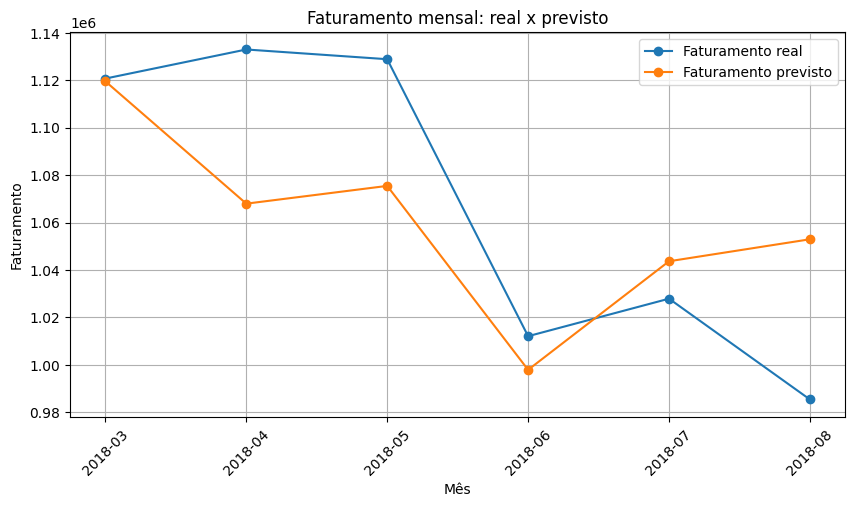

In [39]:
# Gráfico de faturamento real x previsto

plt.figure(figsize=(10, 5))

plt.plot(
    resultado_predicao["mes_compra"],
    resultado_predicao["faturamento_real"],
    marker="o",
    label="Faturamento real"
)

plt.plot(
    resultado_predicao["mes_compra"],
    resultado_predicao["faturamento_previsto"],
    marker="o",
    label="Faturamento previsto"
)

plt.title("Faturamento mensal: real x previsto")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# Exportar resultado da análise preditiva

resultado_predicao.to_csv("resultado_predicao_faturamento.csv", index=False)

print("Arquivo gerado com sucesso:")
print("resultado_predicao_faturamento.csv")

Arquivo gerado com sucesso:
resultado_predicao_faturamento.csv
